In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/heart-disease-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

#Importing Dataset

In [ ]:
data = pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
data.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


#Using Decision Tree Classifier

In [ ]:
X = data.drop('target', axis=1)
y = data['target']

In [ ]:
print("Input: \n",X)
print("\nOutput: \n", y)

Input: 
       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0   

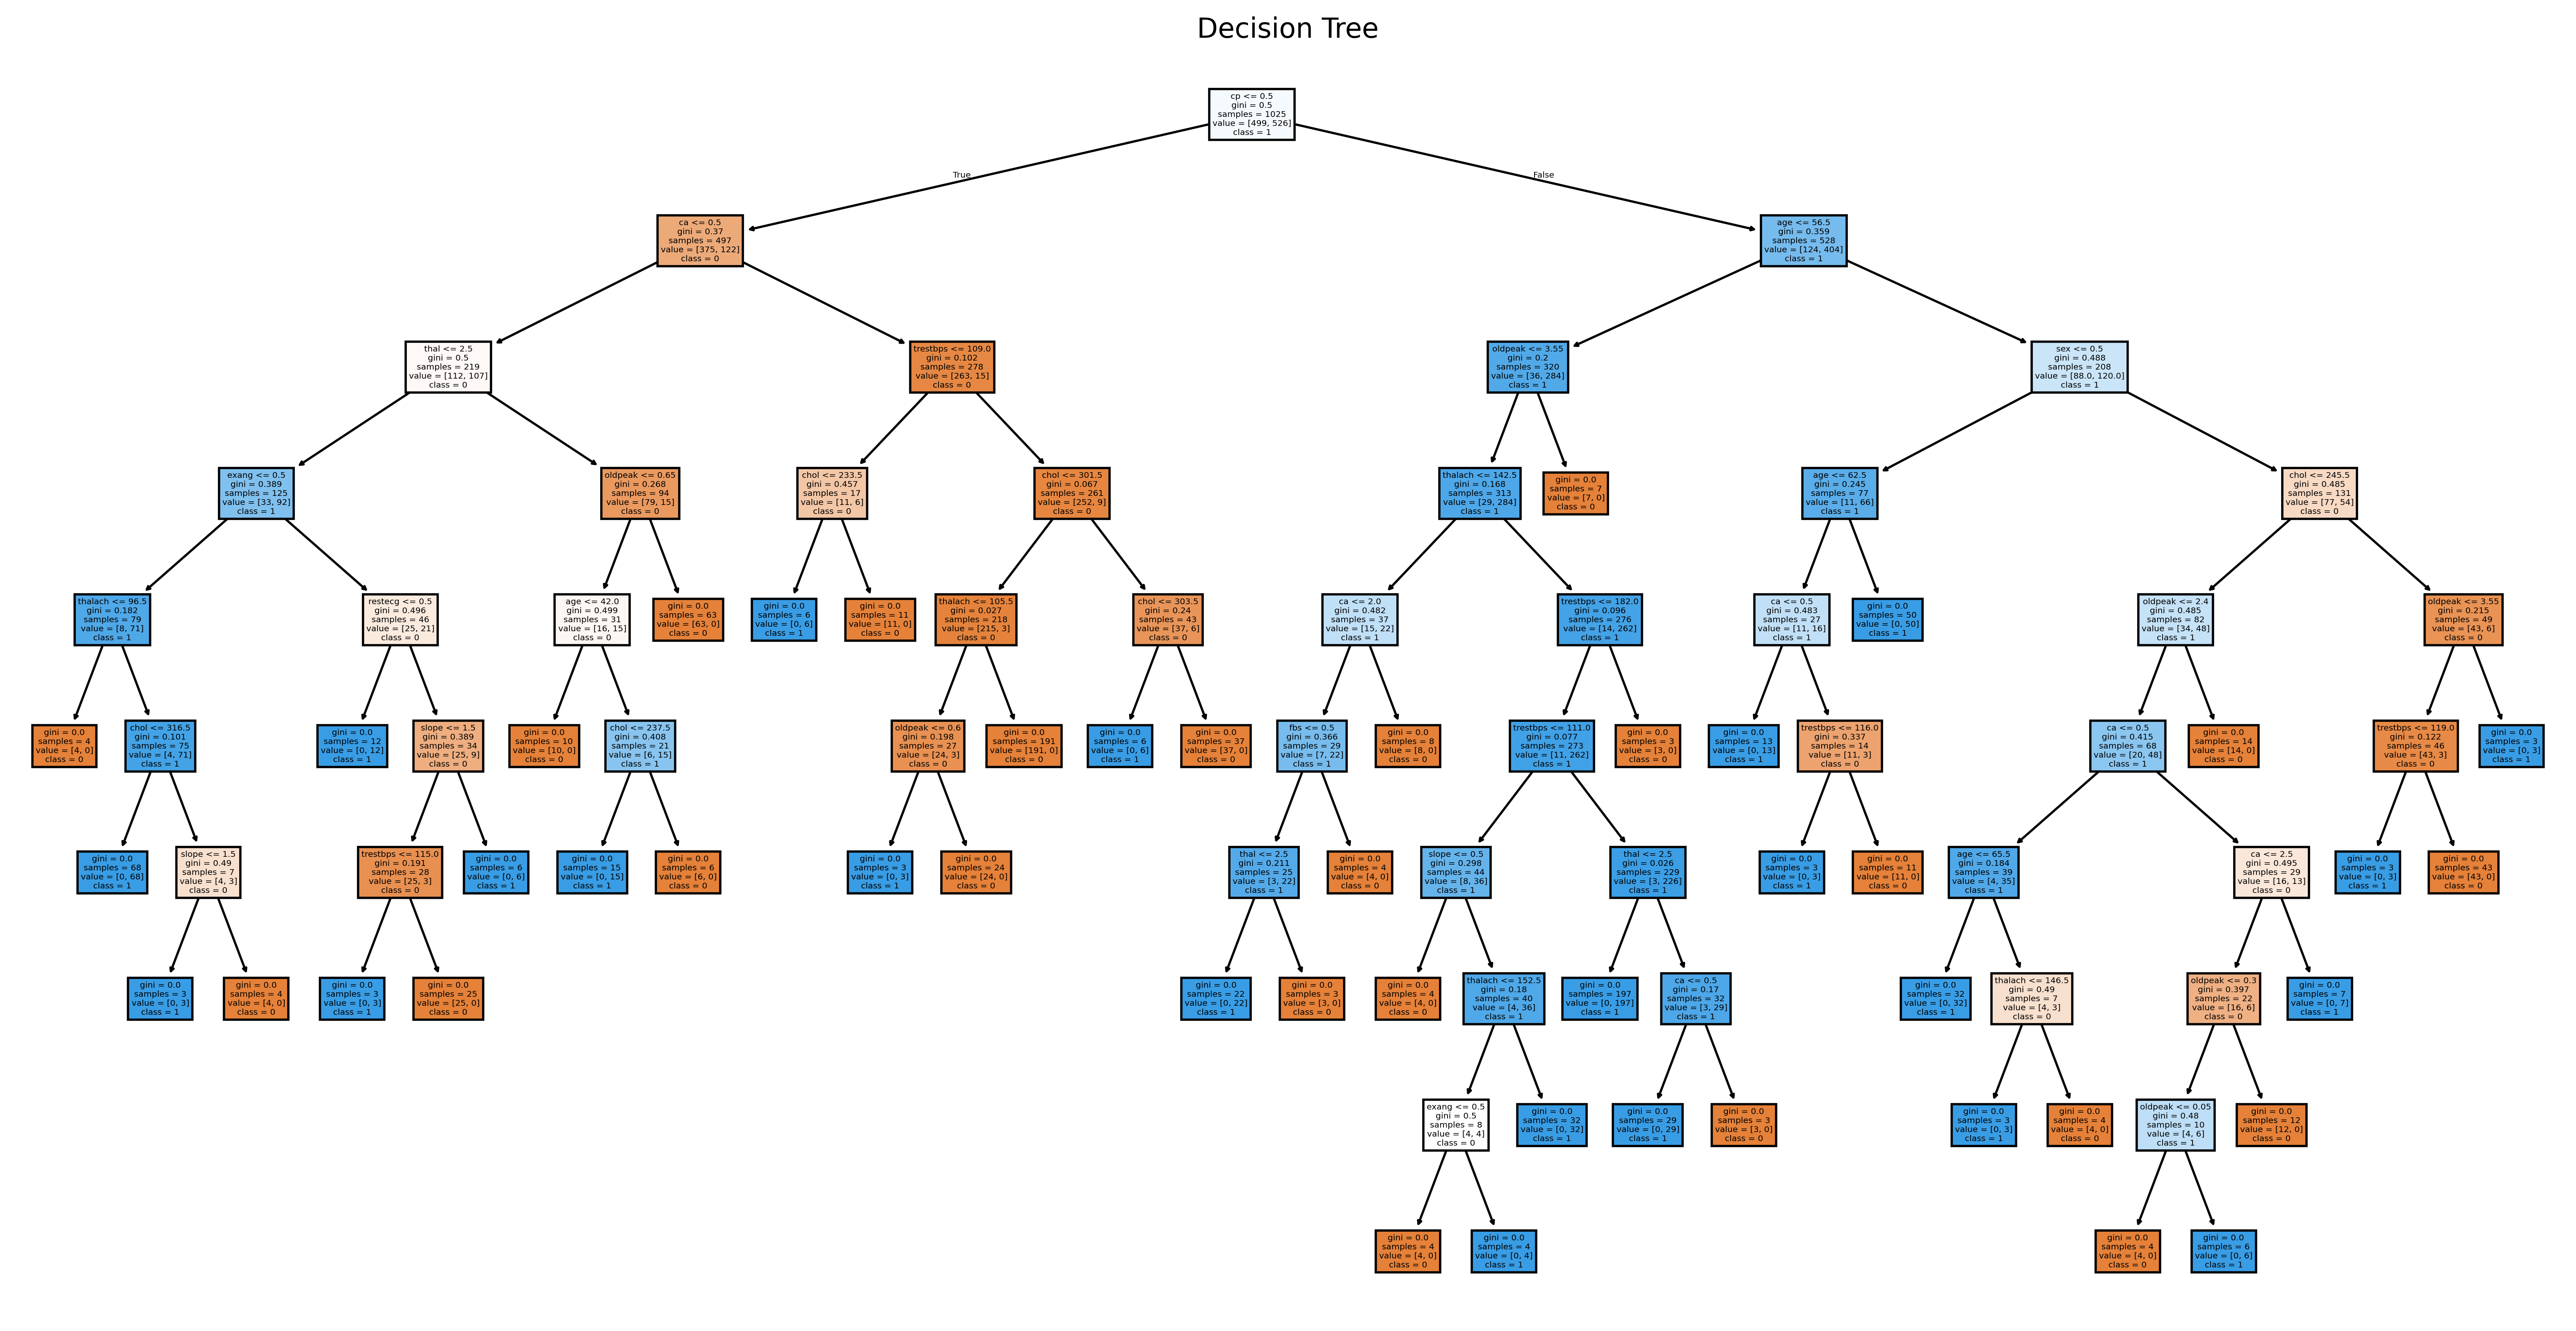

In [ ]:
modelDT = DecisionTreeClassifier(random_state=42)
modelDT.fit(X, y)

plt.figure(figsize=(20,10), dpi= 400)
plot_tree(modelDT, filled=True, feature_names= X.columns, class_names= y.unique().astype(str))
plt.title('Decision Tree')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelDT = DecisionTreeClassifier(random_state=42)
modelDT.fit(X_train, y_train)

train_acc = accuracy_score(y_train, modelDT.predict(X_train))
test_acc = accuracy_score(y_test, modelDT.predict(X_test))
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9708


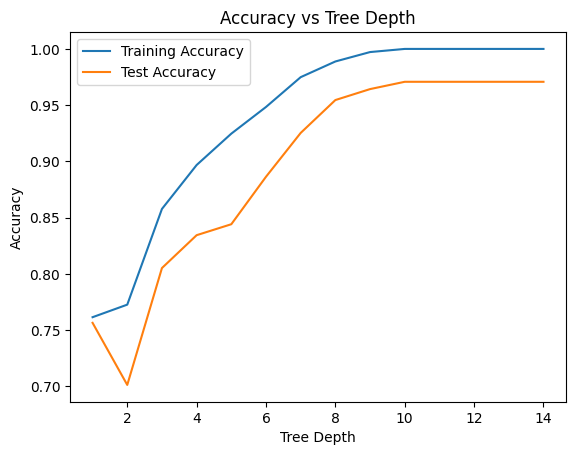

In [ ]:
train_accuracies = []
test_accuracies = []
depths = range(1, 15)

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_accuracies, label='Training Accuracy')
plt.plot(depths, test_accuracies, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Tree Depth')
plt.show()

In [ ]:
modelDT = DecisionTreeClassifier(max_depth=8, random_state=42)
modelDT.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, random_state=42)

In [ ]:
train_acc = accuracy_score(y_train, modelDT.predict(X_train))
test_acc = accuracy_score(y_test, modelDT.predict(X_test))
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 0.9888
Test Accuracy: 0.9545


#Using Random Forest

In [ ]:
modelRF = RandomForestClassifier(n_estimators=100, random_state=42)
modelRF.fit(X_train, y_train)

y_train_pred_rf = modelRF.predict(X_train)
y_test_pred_rf = modelRF.predict(X_test)

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Random Forest Training Accuracy: {train_acc_rf:.4f}")
print(f"Random Forest Test Accuracy: {test_acc_rf:.4f}")


Random Forest Training Accuracy: 1.0000
Random Forest Test Accuracy: 0.9805


In [ ]:
importancesDT = modelDT.feature_importances_
importancesRF = modelRF.feature_importances_


feat_importancesDT = pd.DataFrame({'Feature': X.columns, 'Importance': importancesDT})
feat_importancesDT = feat_importancesDT.sort_values(by='Importance', ascending=False)

print(feat_importancesDT)

     Feature  Importance
2         cp    0.280200
12      thal    0.158504
11        ca    0.133061
9    oldpeak    0.089088
4       chol    0.067806
0        age    0.059076
7    thalach    0.055881
3   trestbps    0.054684
10     slope    0.039724
1        sex    0.028811
6    restecg    0.016755
8      exang    0.016409
5        fbs    0.000000


In [ ]:
feat_importancesRF = pd.DataFrame({'Feature': X.columns, 'Importance': importancesRF})
feat_importancesRF = feat_importancesRF.sort_values(by='Importance', ascending=False)

print(feat_importancesRF)

     Feature  Importance
2         cp    0.132274
7    thalach    0.125039
11        ca    0.122912
9    oldpeak    0.122852
12      thal    0.113005
0        age    0.085554
4       chol    0.079872
3   trestbps    0.068356
10     slope    0.051335
8      exang    0.042210
1        sex    0.028721
6    restecg    0.018155
5        fbs    0.009714


#Cross Validation

In [ ]:
cv_scores_DT = cross_val_score(modelDT, X, y, cv=5)

print("Cross-Validation Scores:", cv_scores_DT)
print("Mean CV Accuracy: {:.4f}".format(cv_scores_DT.mean()))

Cross-Validation Scores: [0.99512195 1.         0.97073171 0.9804878  0.9902439 ]
Mean CV Accuracy: 0.9873


In [ ]:
cv_scores_RF = cross_val_score(modelRF, X, y, cv=5)

print("Cross-Validation Scores:", cv_scores_RF)
print("Mean CV Accuracy: {:.4f}".format(cv_scores_RF.mean()))

Cross-Validation Scores: [1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9971
